IMPORT PACZEK

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import slab
import pickle
from glob import glob
from mtrf.model import TRF
import os
import re

PARAMETRY GLOBALNE

In [102]:
subjects = [f"pilot_{i}" for i in range(7, 10)]

new_fs = 64
tmin, tmax = 0, 0.35
regularization = [0.1, 1, 10, 100]

STIMULUS

In [103]:
def build_stimulus(wav_files, idyom_df, log_df):
    mvar_stimulus = []

    for wf in wav_files:

        fname = os.path.basename(wf)

        # audio
        sound = slab.Sound(wf).channel(0).resample(int(44100 / 3))

        env = sound.envelope().resample(new_fs).data.reshape(-1, 1)

        onsets = np.diff(env, axis=0, prepend=0)
        onsets[onsets < 0] = 0

        n_samples = len(env)

        # IDYOM
        stim_id = extract_id(fname)

        if stim_id not in idyom_df:
            raise ValueError(f"Missing IDYOM entry for {fname} (id={stim_id})")

        ic = np.asarray(idyom_df[stim_id]["IC"]).reshape(-1, 1)
        ent = np.asarray(idyom_df[stim_id]["entropy"]).reshape(-1, 1)

        # align length
        L = min(n_samples, len(ic), len(ent))

        env = env[:L]
        onsets = onsets[:L]
        ic = ic[:L]
        ent = ent[:L]

        # harmonicity (from log)
        trial = log_df[log_df["filename"] == fname]

        if len(trial) > 0:
            is_harm = 1 if trial["harmonicity"].iloc[0] == "harm" else 0
        else:
            is_harm = 0

        harm = np.full((L, 1), is_harm)

        # FINAL STIMULUS
        stim = np.concatenate([env, onsets, ic, ent, harm], axis=1)
        mvar_stimulus.append(stim)

    return mvar_stimulus


def extract_id(fname):
    return int(re.findall(r'\d+', fname)[0])


def safe_zscore(x):
    x = np.array(x)
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    std[std == 0] = 1
    return (x - mean) / std

GLOBALNA ANALIZA

In [104]:
results_A = []
results_AM = []
results_AMH = []
models_AMH = []


for subject in subjects:

    print(f"\nProcessing {subject}")

    try:

        # PATHS
        fif_path = f"/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/epochs/{subject}_epo.fif"
        log_path = f"/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/logs/{subject}_logs.csv"
        idyom_path = "/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/idyom_vectors.pickle"
        wav_path = "/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/soundpool/*.wav"


        # LOAD
        log_df = pd.read_csv(log_path)

        epochs = mne.read_epochs(fif_path, preload=True).pick_types(eeg=True)
        response = [e.T for e in epochs.get_data()]

        idyom_df = pickle.load(open(idyom_path, "rb"))

        wav_dict = {os.path.basename(f): f for f in glob(wav_path)}

        ordered_fnames = log_df["filename"].values
        ordered_wavs = [wav_dict[f] for f in ordered_fnames if f in wav_dict]

        # STIMULUS
        stim_all = build_stimulus(ordered_wavs, idyom_df, log_df)

        print("stim:", len(stim_all))
        print("resp:", len(response))

        n = min(len(stim_all), len(response))

        stim = stim_all[:n]
        resp = response[:n]

        # ZSCORE
        for i in range(n):
            stim[i] = safe_zscore(stim[i])
            resp[i] = safe_zscore(resp[i])

            if np.isnan(stim[i]).any() or np.isnan(resp[i]).any():
                raise ValueError(f"NaN detected in trial {i}")

        # TRF MODELS

        # A
        trf_A = TRF()
        trf_A.train([s[:, :2] for s in stim], resp,
                    new_fs, tmin, tmax, regularization, k=3)
        _, r_A = trf_A.predict([s[:, :2] for s in stim], resp)

        # AM
        trf_AM = TRF()
        trf_AM.train([s[:, :4] for s in stim], resp,
                     new_fs, tmin, tmax, regularization, k=3)
        _, r_AM = trf_AM.predict([s[:, :4] for s in stim], resp)

        # AMH
        trf_AMH = TRF()
        trf_AMH.train(stim, resp,
                      new_fs, tmin, tmax, regularization, k=3)
        _, r_AMH = trf_AMH.predict(stim, resp)


        # RESULTS
        results_A.append(np.nanmean(r_A))
        results_AM.append(np.nanmean(r_AM))
        results_AMH.append(np.nanmean(r_AMH))

        models_AMH.append(trf_AMH)

        print("OK:", subject)

    except Exception as e:
        print("ERROR:", subject, e)
        continue


print("\nDONE")


Processing pilot_7
Reading /Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/epochs/pilot_7_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...  100000.00 ms
        0 CTF compensation matrices available
Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
stim: 30
resp: 18
ERROR: pilot_7 stimulus and response trials must have the same length!

Processing pilot_8
Reading /Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/epochs/pilot_8_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...  100000.00 ms
        0 CTF compensation matrices available
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
stim: 30
resp: 30
ERROR: pilot_8 stimulus and response tr

WYNIKI MODELI

In [107]:
results_A = np.array(results_A)
results_AM = np.array(results_AM)
results_AMH = np.array(results_AMH)
print("A raw:", results_A)
print("A length:", len(results_A))
print("A:", results_A.mean())
print("AM:", results_AM.mean())
print("AMH:", results_AMH.mean())

A raw: []
A length: 0
A: nan
AM: nan
AMH: nan


/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3325428378.py:6: RuntimeWarning: Mean of empty slice.
  print("A:", results_A.mean())
/Users/kornelia/PycharmProjects/inharmonic_melodies/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3325428378.py:7: RuntimeWarning: Mean of empty slice.
  print("AM:", results_AM.mean())
/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3325428378.py:8: RuntimeWarning: Mean of empty slice.
  print("AMH:", results_AMH.mean())


FIGURE 1 - Music score of a segment of auditory stimulus, with its corresponding features = DO POPRAWY!!!

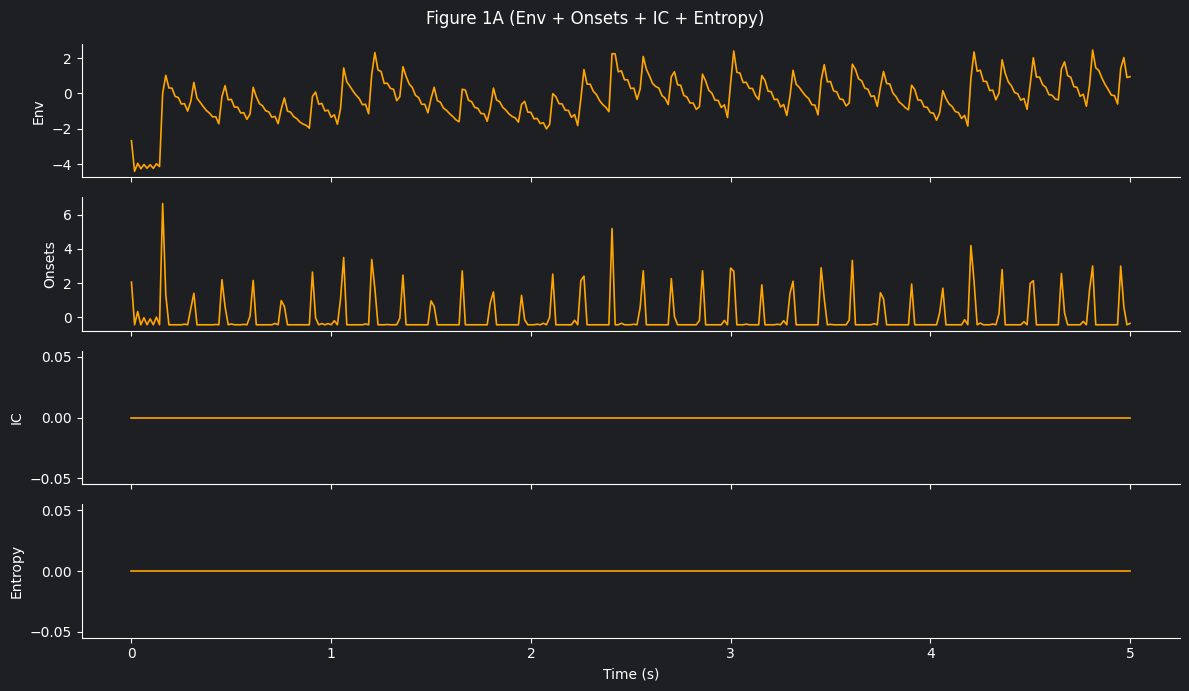

In [115]:
def plot_figure_1a(mvar_stimulus_epoch, fs, start_sec=0, end_sec=5):

    # konwersja triala na array
    mvar_stimulus_epoch = np.array(mvar_stimulus_epoch)

    # bierzemy tylko 4 pierwsze kolumny:
    # Env, Onsets, IC, Entropy
    data = mvar_stimulus_epoch[:, :4]

    # etykiety dopasowane do Twojego modelu
    features = ['Env', 'Onsets', 'IC', 'Entropy']

    # oś czasu
    t = np.arange(data.shape[0]) / fs

    # wycinek czasowy
    mask = (t >= start_sec) & (t <= end_sec)
    t_crop = t[mask]
    d_crop = data[mask, :]

    # figura
    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)

    for i in range(4):
        axes[i].plot(t_crop, d_crop[:, i], color='orange', linewidth=1.2)
        axes[i].set_ylabel(features[i])
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    axes[-1].set_xlabel("Time (s)")
    plt.suptitle("Figure 1A (Env + Onsets + IC + Entropy)")
    plt.tight_layout()
    plt.show()
plot_figure_1a(mvar_stimulus[0], new_fs)

FIGURE 2 - WYKRES PORÓWNUJĄCY MODELA ZE WSZYSTKICH GŁÓW

N subjects: 0
A mean: nan
AM mean: nan
AMH mean: nan


/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3938124466.py:10: RuntimeWarning: Mean of empty slice.
  print("A mean:", results_A.mean())
/Users/kornelia/PycharmProjects/inharmonic_melodies/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3938124466.py:11: RuntimeWarning: Mean of empty slice.
  print("AM mean:", results_AM.mean())
/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3938124466.py:12: RuntimeWarning: Mean of empty slice.
  print("AMH mean:", results_AMH.mean())


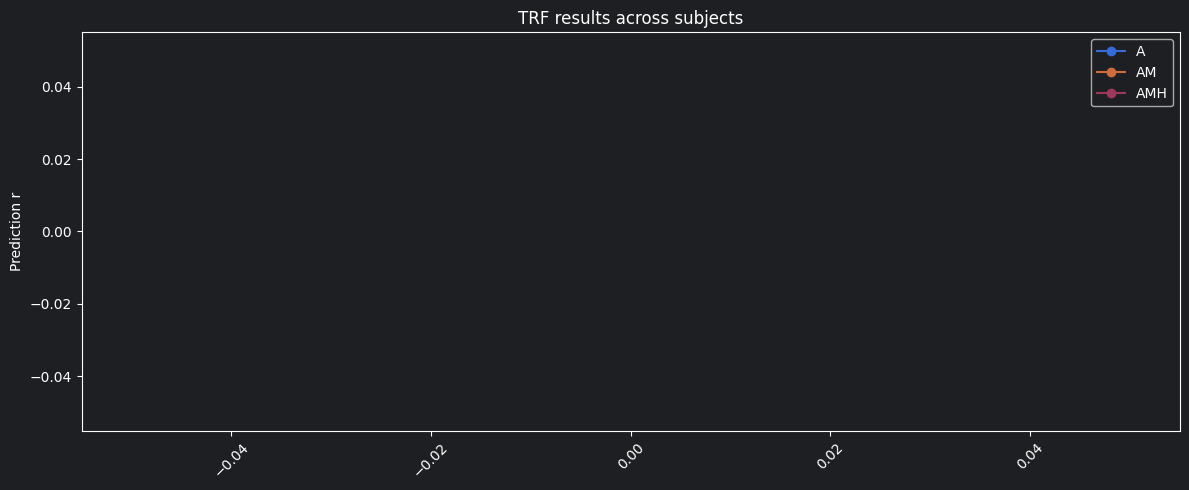

In [112]:
import matplotlib.pyplot as plt
import numpy as np

results_A = np.array(results_A)
results_AM = np.array(results_AM)
results_AMH = np.array(results_AMH)

print("N subjects:", len(results_A))

print("A mean:", results_A.mean())
print("AM mean:", results_AM.mean())
print("AMH mean:", results_AMH.mean())

plt.figure(figsize=(12,5))

labels = [f"P{i}" for i in range(1, len(results_A)+1)]

plt.plot(labels, results_A, marker='o', label='A')
plt.plot(labels, results_AM, marker='o', label='AM')
plt.plot(labels, results_AMH, marker='o', label='AMH')

plt.ylabel("Prediction r")
plt.title("TRF results across subjects")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FIGURE 3 - Ridge regression weights for TRF = DO POPRAWY!!!

In [114]:
def plot_figure_2e(trf_model, channels_idx=[4, 5], ch_names=['Fz', 'Cz', 'Pz']):
    weights = trf_model.weights
    n_features, n_lags, n_channels = weights.shape

    # Etykiety cech zgodnie z kolejnością w Figure 2E
    # Kolejność w artykule od góry: Env, Env', Sp, Hp, So, Ho
    # Dostosowujemy do Twojego modelu AMH (7 cech) - wywalić harm
    features_labels = ['Env', "Env'", 'Sp', 'Hp', 'So', 'Ho']
    features_labels = features_labels[:n_features]

    # tmin i tmax powinny być zgodne z parametrami treningu (np. 0, 0.35)
    lags_ms = np.linspace(tmin * 1000, tmax * 1000, n_lags)

    fig, axes = plt.subplots(len(channels_idx), 1, figsize=(8, 10), sharex=True)

    if len(channels_idx) == 1:
        axes = [axes]

    for i, ch_idx in enumerate(channels_idx):
        if ch_idx >= n_channels:
            continue

        # Wyciągnięcie wag dla danego kanału
        w = weights[:, :, ch_idx]

        # Normalizacja wag dla każdego kanału oddzielnie
        w_norm = w / (np.max(np.abs(w)) + 1e-8)

        im = axes[i].imshow(
            w_norm,
            aspect='auto',
            origin='upper', # Env na górze wykresu
            cmap='RdBu_r',  # Red-Blue reversed: czerwony(+) / niebieski(-) [2, 3]
            extent=[lags_ms, lags_ms[-1], n_features - 0.5, -0.5],
            vmin=-1,
            vmax=1)

        axes[i].set_yticks(np.arange(n_features))
        axes[i].set_yticklabels(features_labels)

        axes[i].set_ylabel(ch_names[i] if i < len(ch_names) else f"Ch {ch_idx}",
                           fontsize=12, fontweight='bold', rotation=0, labelpad=25)

        axes[i].axvline(0, color='black', linewidth=0.8, linestyle='--')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Normalised TRF weights")

    plt.xlabel("Latency (ms)")
    fig.suptitle(f"Figure 2E: TRF Weights - Subject: {subject}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

    plt.tight_layout()
    plt.show()

plot_figure_2e(trf_amh, channels_idx=[0, 1, 2])